In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import WeightedRandomSampler
import pandas as pd

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 15.1 — Transform , Dataset

In [3]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

# 15.2 — WeightedRandomSampler

In [5]:
class_counts = train_df["label"].value_counts()
print("Class counts:",class_counts)

class_weights = {
    class_name: 1.0 / count
    for class_name, count in class_counts.items()
}
print("\nClass weights:",class_weights)

sample_weights = train_df["label"].map(class_weights).values

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts: label
kamyun       756
vanet        580
savari       398
taxi         387
autobus      370
minibus      314
ambulance    289
Name: count, dtype: int64

Class weights: {'kamyun': 0.0013227513227513227, 'vanet': 0.0017241379310344827, 'savari': 0.002512562814070352, 'taxi': 0.002583979328165375, 'autobus': 0.002702702702702703, 'minibus': 0.0031847133757961785, 'ambulance': 0.0034602076124567475}


In [9]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 15.3 — CNN 

In [10]:
class BalancedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
            )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 15.4 — model, loss, optimizer, decive, Scheduler

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_balanced = BalancedCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_balanced.parameters(),
    lr=0.001
)
print("Device:", device)

Device: cpu


# 15.5 — Training loop 

In [12]:
num_epochs = 10

best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model_balanced.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_balanced(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss /len(train_loader)

    # Validation
    model_balanced.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_balanced(images)
            loss = criterion(outputs,labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss /len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_balanced.state_dict(),
            "best_balanced_batches_model.pt"
        )
        print("  --> Best Balanced Batches model saved! ")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:",best_val_accuracy)

  --> Best Balanced Batches model saved! 
Epoch [1/10] Train Loss: 1.3564 Val Loss: 0.7488 Val Accuracy: 0.7558
  --> Best Balanced Batches model saved! 
Epoch [2/10] Train Loss: 0.3359 Val Loss: 0.5999 Val Accuracy: 0.8075
  --> Best Balanced Batches model saved! 
Epoch [3/10] Train Loss: 0.1597 Val Loss: 0.5700 Val Accuracy: 0.8230
Epoch [4/10] Train Loss: 0.1198 Val Loss: 0.6954 Val Accuracy: 0.8127
  --> Best Balanced Batches model saved! 
Epoch [5/10] Train Loss: 0.0685 Val Loss: 0.6585 Val Accuracy: 0.8269
Epoch [6/10] Train Loss: 0.0517 Val Loss: 0.7317 Val Accuracy: 0.8204
Epoch [7/10] Train Loss: 0.0268 Val Loss: 0.7282 Val Accuracy: 0.8269
Epoch [8/10] Train Loss: 0.0335 Val Loss: 0.7822 Val Accuracy: 0.8062
Epoch [9/10] Train Loss: 0.0132 Val Loss: 0.6900 Val Accuracy: 0.8243
Epoch [10/10] Train Loss: 0.0121 Val Loss: 0.8606 Val Accuracy: 0.8191


Best Epoch: 5
Best Validation Accuracy: 0.8268733850129198


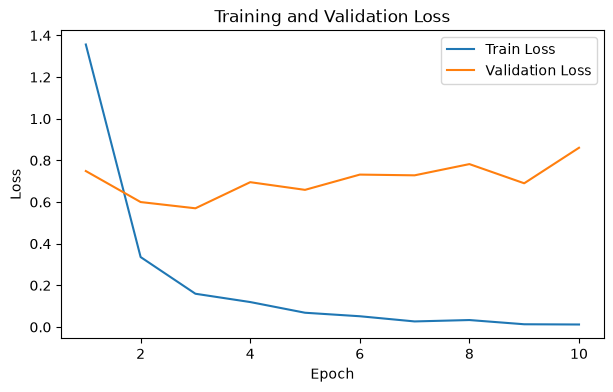

In [13]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

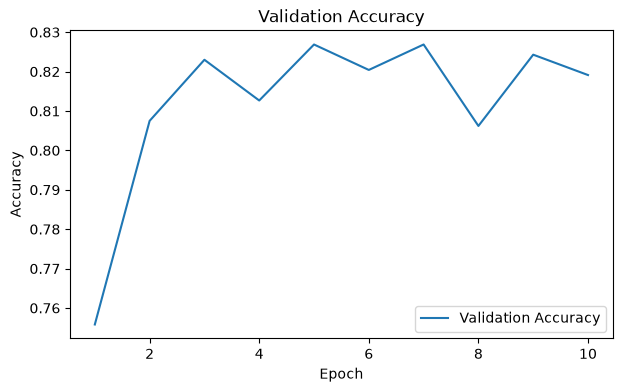

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 15.6 — Checking the number of selected samples

In [15]:
sampled_labels = []
for indices in sampler:
    label = train_df.iloc[indices]["label"]
    sampled_labels.append(label)
    
sampled_labels = pd.Series(sampled_labels)
print(sampled_labels.value_counts())

autobus      461
ambulance    455
minibus      449
taxi         436
kamyun       436
savari       429
vanet        428
Name: count, dtype: int64


# 15.7 — Baseline evaluation on the validation set

In [ ]:
model_balanced.load_state_dict(
    torch.load(
       "best_balanced_batches_model.pt",
        map_location=device
    )
)
model_blnc = model_balanced.to(device)
model_blnc.eval()
print("Best Balanced Batches Model Loaded")

Best Balanced Batches Model Loaded


In [ ]:
all_predictions_BalancedBatches= []
all_labels_BalancedBatches  = []
model_blnc.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_blnc(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_BalancedBatches.extend(predictions.cpu().numpy())
        all_labels_BalancedBatches.extend(labels.cpu().numpy())

print("Predictions:", len(all_predictions_BalancedBatches))
print("Labels:", len(all_labels_BalancedBatches))

Predictions: 774
Labels: 774


# 15.8 — Precision , Recall , F1 , confusion_matrix

In [18]:
accuracy = accuracy_score(all_labels_BalancedBatches, all_predictions_BalancedBatches)
precision = precision_score(all_labels_BalancedBatches, all_predictions_BalancedBatches, average="macro")
recall = recall_score(all_labels_BalancedBatches, all_predictions_BalancedBatches, average="macro")
f1 = f1_score(all_labels_BalancedBatches, all_predictions_BalancedBatches, average="macro")
cm = confusion_matrix(all_labels_BalancedBatches, all_predictions_BalancedBatches)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.8268733850129198
Validation Precision: 0.8415368227217327
Validation Recall   : 0.8247002909773441
Validation F1 Score : 0.8281338248568014
confusion_matrix    :
 [[ 53   0  10   2   4   0   3]
 [  0  72  14   1   3   3   0]
 [  5   4 159  15   2   3   1]
 [  0   0  16  62   0   0   0]
 [  1   2   0   0  94   1   2]
 [  0   2   4   0   1  90   0]
 [  1   2   7   1  23   1 110]]


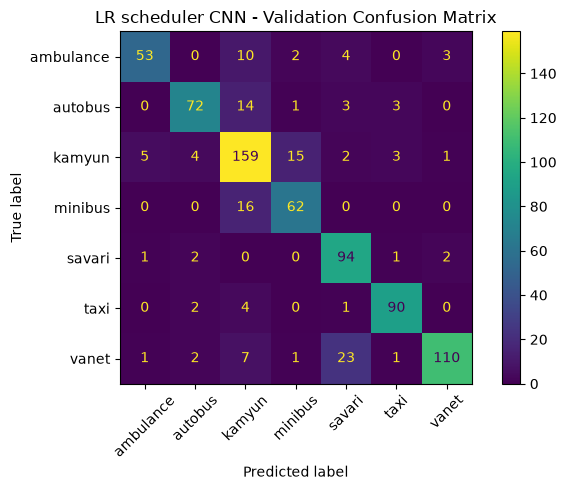

In [19]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("LR scheduler CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [20]:
report = classification_report(all_labels_BalancedBatches, all_predictions_BalancedBatches, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.88      0.74      0.80        72
     autobus       0.88      0.77      0.82        93
      kamyun       0.76      0.84      0.80       189
     minibus       0.77      0.79      0.78        78
      savari       0.74      0.94      0.83       100
        taxi       0.92      0.93      0.92        97
       vanet       0.95      0.76      0.84       145

    accuracy                           0.83       774
   macro avg       0.84      0.82      0.83       774
weighted avg       0.84      0.83      0.83       774

